**The Channels: 180**

This is usually the most confusing part. In a normal CNN, channels are just arbitrary filters. In the  Digital ZZ setup, they represent specific physical measurements.The formula for your 180 channels is:$$\text{Total Channels} = \text{Topologies} \times (\text{Single Z Measurements} + \text{ZZ Correlator Pairs})$$


**Topologies (4):** We used Kings, Horizontal, Vertical, and Ring. Each topology arranges the 9 qubits differently, meaning they "view" the 3x3 patch from different geometric perspectives.

**Measurements per Topology (45):** 

9 Single-Z: We measure the expectation value $\langle Z \rangle$ of each of the 9 qubits.

36 ZZ-Pairs: We measure the correlation $\langle Z_i Z_j \rangle$ between pairs of qubits. (Since we have 9 qubits, there are $\binom{9}{2} = 36$ possible unique pairs).

Total: $4 \times (9 + 36) = 180$.

 File Loaded: breastmnist_A100_final_tkin-hor-ver-rin.npz
--------------------------------------------------
 Metadata Found:
   > topologies: ['kings', 'horizontal', 'vertical', 'ring']
   > hardware: 128_core_sbatch
--------------------------------------------------
 TRAIN Split:
   > Features shape: (546, 180, 9, 9)  (Expected: [Samples, 180, 9, 9])
   > Labels shape:   (546,)    (Expected: [Samples,])
   > Value Range:    [-0.9227, 0.9245]
   > Mean Intensity: 0.1846

 VAL Split:
   > Features shape: (78, 180, 9, 9)  (Expected: [Samples, 180, 9, 9])
   > Labels shape:   (78,)    (Expected: [Samples,])
   > Value Range:    [-0.9178, 0.9241]
   > Mean Intensity: 0.1859

 TEST Split:
   > Features shape: (156, 180, 9, 9)  (Expected: [Samples, 180, 9, 9])
   > Labels shape:   (156,)    (Expected: [Samples,])
   > Value Range:    [-0.9214, 0.9233]
   > Mean Intensity: 0.1804



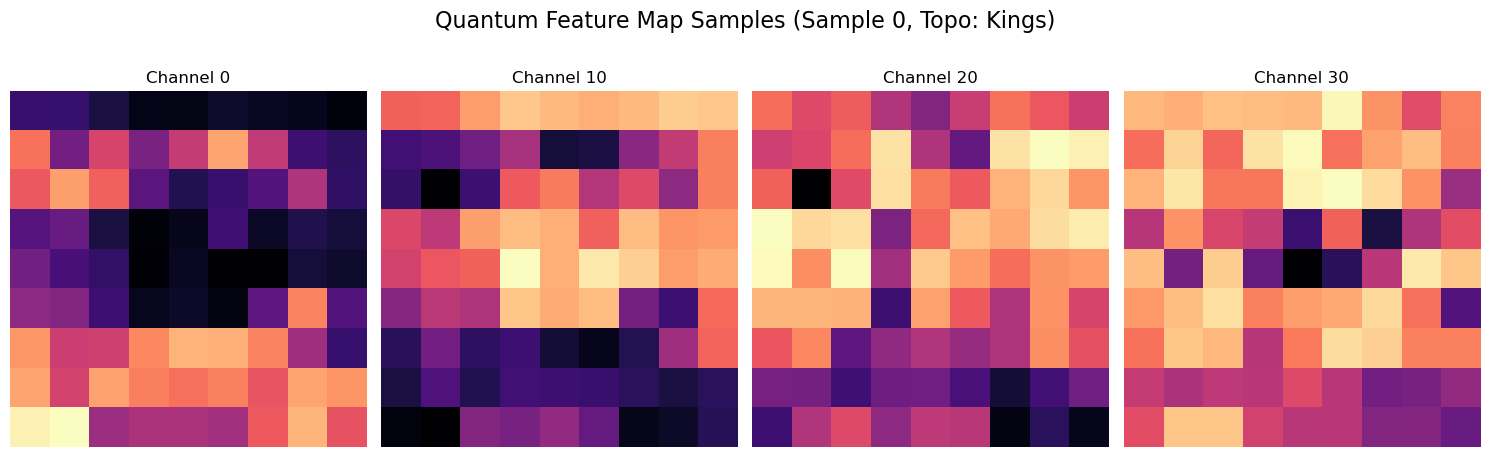

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# 1. Setup Path
DATA_PATH = Path("/scratch/sp7007/MoT-DAQCNN/data/quantum_datasets/breastmnist_A100_final_tkin-hor-ver-rin.npz")

# 2. Load the Data
data = np.load(DATA_PATH, allow_pickle=True)

print(f" File Loaded: {DATA_PATH.name}")
print("-" * 50)

# 3. Check Metadata
if 'metadata' in data:
    metadata = json.loads(str(data['metadata']))
    print(" Metadata Found:")
    for k, v in metadata.items():
        print(f"   > {k}: {v}")
else:
    print("No metadata found in file.")

print("-" * 50)

# 4. Verify Dimensions
splits = ['train', 'val', 'test']
for split in splits:
    features = data[f'{split}_features']
    labels = data[f'{split}_labels']
    
    print(f" {split.upper()} Split:")
    print(f"   > Features shape: {features.shape}  (Expected: [Samples, 180, 9, 9])")
    print(f"   > Labels shape:   {labels.shape}    (Expected: [Samples,])")
    
    # Check for NaNs or Infinite values
    if np.isnan(features).any():
        print(f"   WARNING: NaNs detected in {split} features!")
    if np.all(features == 0):
        print(f"   WARNING: {split} features are all zeros!")
    
    # Statistical check
    print(f"   > Value Range:    [{features.min():.4f}, {features.max():.4f}]")
    print(f"   > Mean Intensity: {features.mean():.4f}")
    print("")

# 5. Visual Inspection
# Let's look at the first image's quantum feature maps
sample_idx = 0
topo_idx = 0 # Look at the first topology (out of 4)
channel_idx = 0 # Look at the first measurement (out of 45)

# Calculate which index in the 180 channels we want to see
# 180 channels = 4 topologies * 45 measurements each
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle(f"Quantum Feature Map Samples (Sample {sample_idx}, Topo: Kings)", fontsize=16)

for i in range(4):
    # Display 4 different measurement channels from the first topology
    axes[i].imshow(data['train_features'][sample_idx, i*10, :, :], cmap='magma')
    axes[i].set_title(f"Channel {i*10}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()